# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

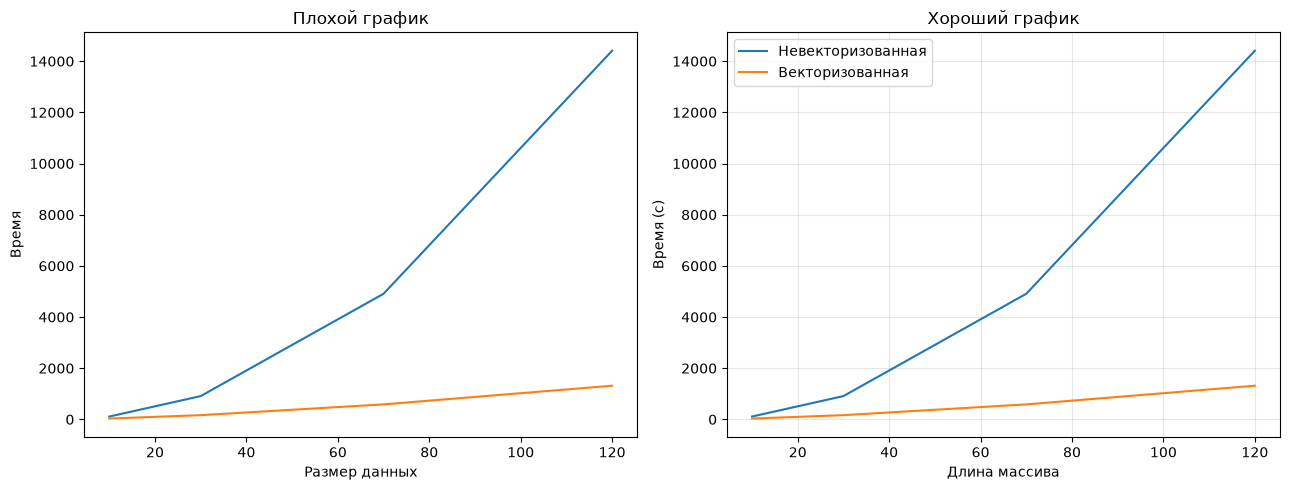

In [1]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import time

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

In [2]:
reload_solution_modules()

X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])

functions.prod_non_zero_diag(X)
functions_vectorized.prod_non_zero_diag(X)

TIME: 0.00001
TIME: 0.00004


 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


In [3]:
reload_solution_modules()

x = np.array([1, 2, 2, 4])
y = np.array([4, 2, 1, 2])

functions.are_multisets_equal(x, y)
functions_vectorized.are_multisets_equal(x, y)

TIME: 0.00002
TIME: 0.00906


* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

In [4]:
reload_solution_modules()

x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])

functions.max_after_zero(x)
functions_vectorized.max_after_zero(x)

TIME: 0.00004
TIME: 0.00003


 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


TIME: 2.28070
TIME: 0.02192


TypeError: Image data of dtype object cannot be converted to float

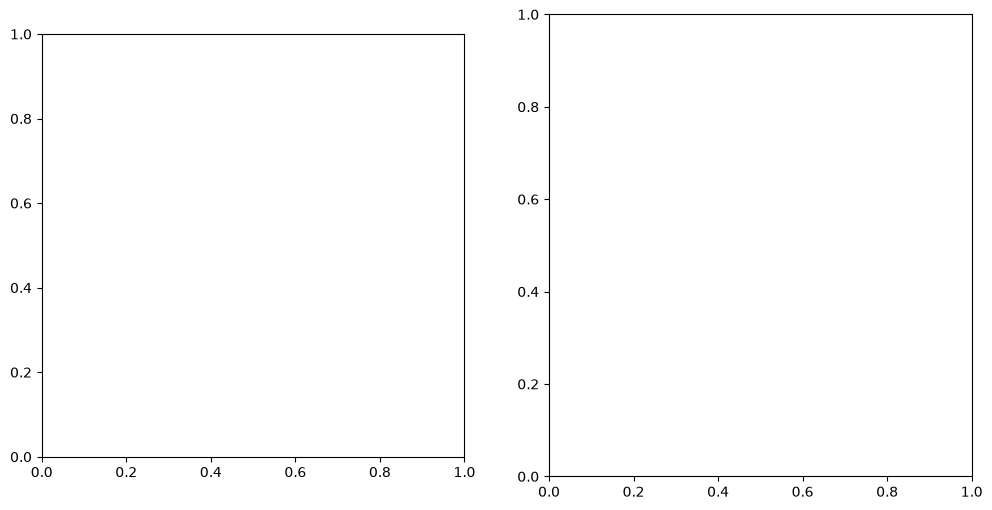

In [5]:
reload_solution_modules()
import PIL
from PIL import Image

image = np.asarray(Image.open('./avatar.jpg').convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])

common = functions.convert_image(image, coefs)
vectorized = functions_vectorized.convert_image(image, coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(common, cmap='gray')
axes[0].set_title("common convert")
axes[0].axis('off')

axes[1].imshow(vectorized, cmap='gray') 
axes[1].set_title("vectorized convert")
axes[1].axis('off')

plt.tight_layout()
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

In [ ]:
reload_solution_modules()

x = np.array([2, 2, 2, 3, 3, 3, 5])

common = functions.run_length_encoding(x)
vectorized = functions_vectorized.run_length_encoding(x)

print(
    common,
    vectorized,
    sep='\n'
)

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

In [ ]:
reload_solution_modules()
import scipy

X = np.array([
    [2, 3, 4, 5],
    [2, 3, 4, 5],
    [2, 3, 4, 5],
    [2, 3, 4, 5],
             ])
Y = np.array([
    [4, 5, 6, 7],
    [4, 5, 6, 7],
    [4, 5, 6, 7],
    [4, 5, 6, 7],
])

common_start = time.perf_counter()
common = functions.pairwise_distance(X, Y)
common_end = time.perf_counter()

vectorized_start = time.perf_counter()
vectorized = functions_vectorized.pairwise_distance(X, Y)
vectorized_end = time.perf_counter()

scipyed_start = time.perf_counter()
scipyed = scipy.spatial.distance.cdist(X, Y)
scipyed_end = time.perf_counter()

print('======= TIME =======',
      f'common: {(common_end - common_start):.5f}',
      f'vectorized: {(vectorized_end - vectorized_start):.5f}',
      f'scipy: {(scipyed_end - scipyed_start):.5f}',
      '====================',
     sep='\n')

print(
    common,
    vectorized,
    scipyed,
    sep='\n'
)

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# *I* ```use``` __Obsidian__ ~~btw~~ *__:3__*

# What
## Level
### Of
#### Header
##### You
###### Want?